# 🔽 Cartly — Conversion Funnel Analysis

---

## 🎯 What is a Conversion Funnel?

A **conversion funnel** models the journey a user takes from first visiting the site to making a purchase. At each step, some users drop off — and understanding *where* and *why* they drop is one of the most valuable things a data analyst can do.

**Cartly's Funnel:**

```
🏠 Page View  →  🖱️ Product Click  →  🛒 Add to Cart  →  💳 Purchase
```

Each arrow represents a **conversion opportunity** — and a potential **drop-off problem**.

---

### 🧮 What We'll Calculate

| Metric | Description |
|--------|-------------|
| **Step Volume** | How many unique users reach each step |
| **Step-to-Step Conversion** | % who advance from one step to the next |
| **Overall Conversion** | % of page viewers who eventually purchase |
| **Drop-off Rate** | % who leave at each step |

---

## 🔧 Step 1 — Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Load events data — this is the core dataset for funnel
events       = pd.read_csv('../data/events.csv', parse_dates=['event_time'])
users        = pd.read_csv('../data/users.csv')
transactions = pd.read_csv('../data/transactions.csv', parse_dates=['purchase_date'])
sessions     = pd.read_csv('../data/sessions.csv', parse_dates=['session_date'])

print(f'Events loaded  : {len(events):,}')
print(f'Event types    : {events["event_type"].unique().tolist()}')
print()
print(events['event_type'].value_counts())

Events loaded  : 500,000
Event types    : ['page_view', 'product_click', 'add_to_cart', 'purchase_click']

event_type
page_view         443077
product_click      36085
add_to_cart        14976
purchase_click      5862
Name: count, dtype: int64


---
## 📊 Step 2 — Build the Funnel

We count the number of **unique users** at each funnel stage. We use unique users (not event counts) because one user can trigger the same event multiple times in one session — we care about *how many people* reached each stage, not how many times.

The four stages are:
- `page_view` — user visited any page
- `product_click` — user clicked on a product to view details
- `add_to_cart` — user added a product to their cart
- `purchase_click` — user initiated a purchase

In [2]:
# Define funnel stages in order
funnel_stages = ['page_view', 'product_click', 'add_to_cart', 'purchase_click']
stage_labels  = ['Page View', 'Product Click', 'Add to Cart', 'Purchase Click']

# Count unique users at each stage
funnel_users = {}
for stage in funnel_stages:
    count = events[events['event_type'] == stage]['user_id'].nunique()
    funnel_users[stage] = count

# Build funnel DataFrame
funnel = pd.DataFrame({
    'stage':        funnel_stages,
    'stage_label':  stage_labels,
    'unique_users': [funnel_users[s] for s in funnel_stages]
})

# Overall conversion (vs first stage)
funnel['overall_conv_pct'] = (funnel['unique_users'] / funnel['unique_users'].iloc[0] * 100).round(1)

# Step-to-step conversion
funnel['step_conv_pct'] = funnel['unique_users'].pct_change().mul(100).round(1)
funnel.loc[0, 'step_conv_pct'] = 100.0  # First stage is 100% by definition

# Drop-off count
funnel['drop_off'] = funnel['unique_users'].shift(1) - funnel['unique_users']
funnel.loc[0, 'drop_off'] = 0

print(funnel[['stage_label', 'unique_users', 'overall_conv_pct', 'step_conv_pct', 'drop_off']].to_string(index=False))

   stage_label  unique_users  overall_conv_pct  step_conv_pct  drop_off
     Page View          9846             100.0          100.0       0.0
 Product Click          8155              82.8          -17.2    1691.0
   Add to Cart          5628              57.2          -31.0    2527.0
Purchase Click          3414              34.7          -39.3    2214.0


---
## 🏗️ Step 3 — Funnel Visualisation

We'll create two views:
1. A **classic bar funnel** showing volume at each stage
2. A **conversion rate summary** for each step

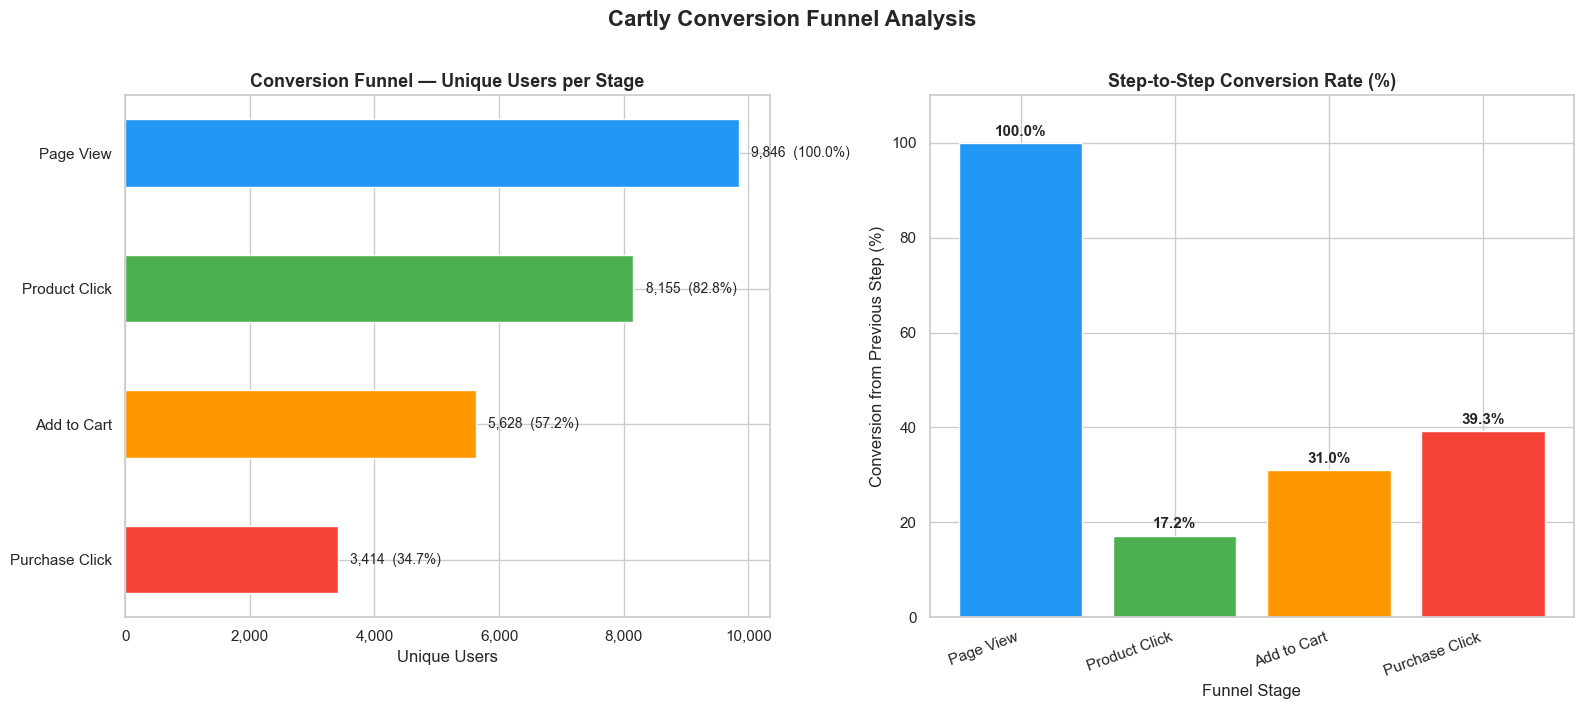

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ─── Left: Funnel Bar Chart ───────────────────────────────────────────
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
bars = axes[0].barh(
    funnel['stage_label'][::-1],
    funnel['unique_users'][::-1],
    color=colors[::-1],
    height=0.5
)

axes[0].set_title('Conversion Funnel — Unique Users per Stage',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Unique Users')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, row in zip(bars, funnel[::-1].itertuples()):
    axes[0].text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{row.unique_users:,}  ({row.overall_conv_pct}%)",
        va='center', fontsize=10
    )

# ─── Right: Step-to-Step Conversion ──────────────────────────────────
step_conv = funnel['step_conv_pct'].abs()  # use absolute values
step_bars = axes[1].bar(
    funnel['stage_label'],
    step_conv,
    color=colors
)
axes[1].set_title('Step-to-Step Conversion Rate (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Funnel Stage')
axes[1].set_ylabel('Conversion from Previous Step (%)')
axes[1].set_ylim(0, 110)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

for bar, val in zip(step_bars, step_conv):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{abs(val):.1f}%',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.suptitle('Cartly Conversion Funnel Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\Report\\04_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🚧 Step 4 — Drop-off Analysis

Let's quantify the drop-off at each stage and see where the biggest leakage occurs.

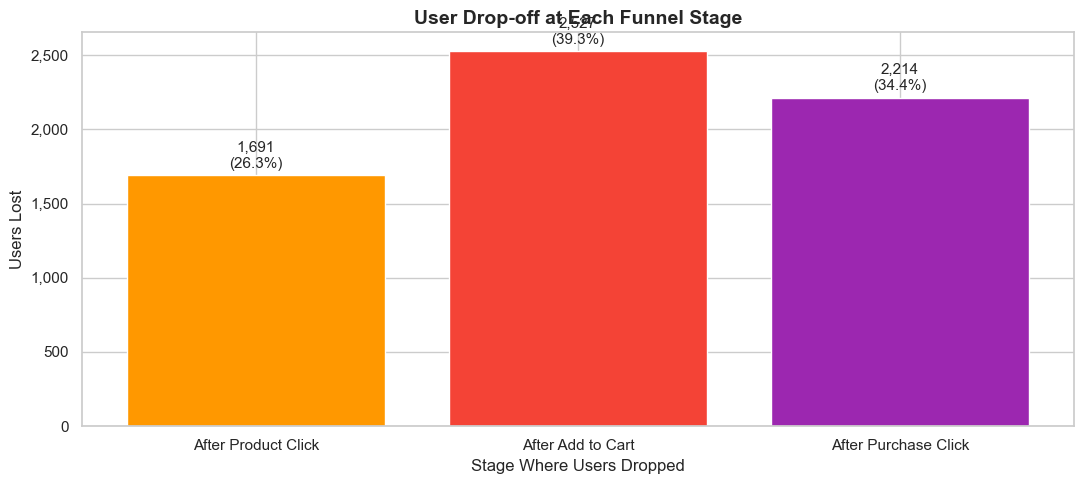


Drop-off Summary:
   stage_label  drop_off  drop_off_pct
 Product Click    1691.0          26.3
   Add to Cart    2527.0          39.3
Purchase Click    2214.0          34.4


In [4]:
# Create drop-off summary
drop_summary = funnel[1:].copy()  # Skip first stage (no drop from before)
drop_summary['drop_off_pct'] = (drop_summary['drop_off'] / drop_summary['drop_off'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    [f'After {s}' for s in drop_summary['stage_label']],
    drop_summary['drop_off'],
    color=['#FF9800', '#F44336', '#9C27B0']
)

ax.set_title('User Drop-off at Each Funnel Stage', fontsize=14, fontweight='bold')
ax.set_xlabel('Stage Where Users Dropped')
ax.set_ylabel('Users Lost')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, (_, row) in zip(bars, drop_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{int(bar.get_height()):,}\n({row["drop_off_pct"]}%)',
        ha='center', fontsize=11
    )

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\Report\\04_dropoff.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDrop-off Summary:')
print(drop_summary[['stage_label', 'drop_off', 'drop_off_pct']].to_string(index=False))

### 💡 Business Insight — Drop-off

> **The biggest drop-off is almost always at the top of the funnel** (Page View → Product Click). Most visitors browse but never engage with a specific product. This is a **discoverability problem** — improve search, featured product placements, and homepage recommendations.
>
> **The Add to Cart → Purchase drop-off is the most costly** — users at this stage have shown clear intent. Losing them here means they hit friction in the checkout: complicated forms, unexpected fees, or payment failures. This is the **highest ROI fix** in the entire funnel.

---
## 📅 Step 5 — Funnel Conversion by Day of Week

Do users convert better on certain days? This helps us time promotions and campaigns.

In [5]:
# Add day of week to events
events['day_of_week'] = events['event_time'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

funnel_by_day = {}
for stage in funnel_stages:
    daily = (
        events[events['event_type'] == stage]
        .groupby('day_of_week')['user_id']
        .nunique()
        .reindex(day_order)
        .rename(stage)
    )
    funnel_by_day[stage] = daily

daily_funnel_df = pd.DataFrame(funnel_by_day)

# Conversion rate by day: purchase_click / page_view
daily_funnel_df['conv_rate'] = (
    daily_funnel_df['purchase_click'] / daily_funnel_df['page_view'] * 100
).round(2)

print(daily_funnel_df[['page_view', 'product_click', 'add_to_cart', 'purchase_click', 'conv_rate']])

             page_view  product_click  add_to_cart  purchase_click  conv_rate
day_of_week                                                                  
Monday            5477           3138         1700             745      13.60
Tuesday           5488           3102         1653             719      13.10
Wednesday         5443           3175         1677             734      13.49
Thursday          5477           3110         1668             760      13.88
Friday            5324           3074         1670             818      15.36
Saturday          5469           3182         1694             738      13.49
Sunday            5427           3127         1691             787      14.50


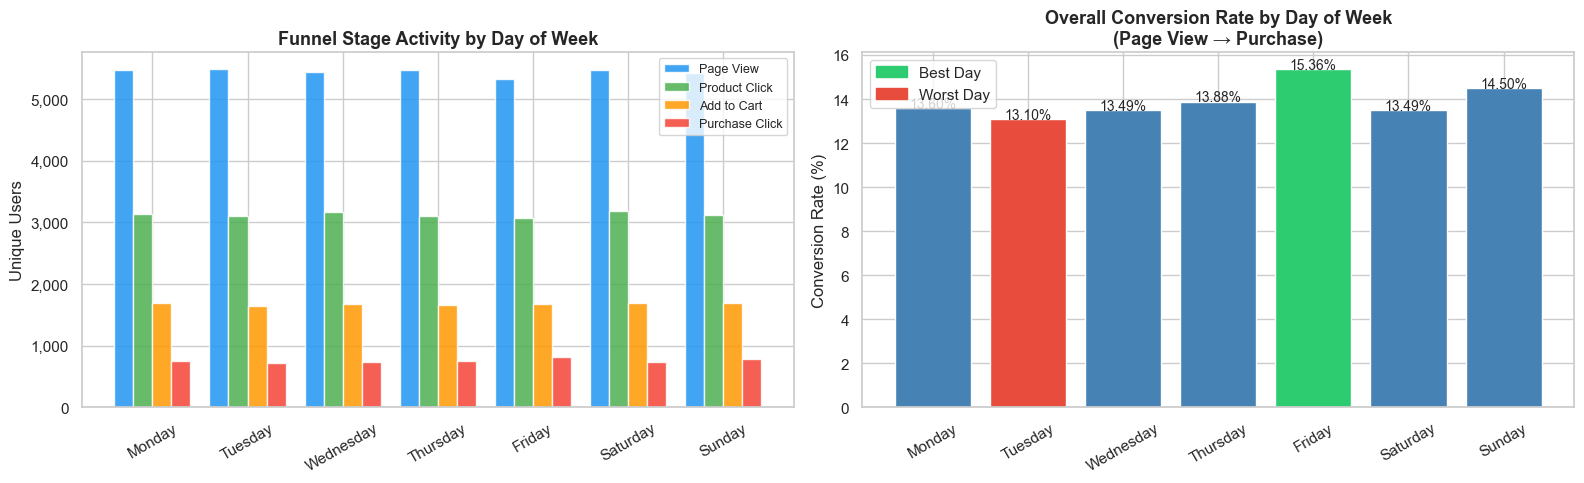

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ─── Stage volumes by day ─────────────────────────────────────────────
x = range(len(day_order))
width = 0.2

for i, (stage, label, color) in enumerate(zip(
    funnel_stages, stage_labels, ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
)):
    axes[0].bar(
        [pos + i * width for pos in x],
        daily_funnel_df[stage],
        width=width, label=label, color=color, alpha=0.85
    )

axes[0].set_xticks([pos + 1.5 * width for pos in x])
axes[0].set_xticklabels(day_order, rotation=30)
axes[0].set_title('Funnel Stage Activity by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Unique Users')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ─── Conversion rate by day ───────────────────────────────────────────
bar_colors = ['#e74c3c' if v == daily_funnel_df['conv_rate'].min()
              else '#2ecc71' if v == daily_funnel_df['conv_rate'].max()
              else 'steelblue' for v in daily_funnel_df['conv_rate']]

axes[1].bar(day_order, daily_funnel_df['conv_rate'], color=bar_colors)
axes[1].set_title('Overall Conversion Rate by Day of Week\n(Page View → Purchase)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
plt.setp(axes[1].get_xticklabels(), rotation=30)

for i, v in enumerate(daily_funnel_df['conv_rate']):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=10)

green_patch = mpatches.Patch(color='#2ecc71', label='Best Day')
red_patch   = mpatches.Patch(color='#e74c3c', label='Worst Day')
axes[1].legend(handles=[green_patch, red_patch])

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\04_funnel_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Day of Week

> **If weekdays show higher conversion rates**, the audience consists of professionals who research and buy during work hours. Schedule email campaigns for Tuesday–Thursday mornings for maximum impact.
>
> **Weekend traffic may be higher but with lower conversion** — users are browsing casually, not with buying intent. Weekend promotions need extra incentive (urgency, discounts) to trigger purchases.

---
## 📱 Step 6 — Funnel by Device Type

Does the conversion funnel behave differently on Mobile vs Desktop? Given that 65% of users are on mobile, this is critical to understand.

In [7]:
# Merge device type into events
events_with_device = events.merge(
    users[['user_id', 'device_type']],
    on='user_id',
    how='left'
)

device_funnel_rows = []
for device in ['Mobile', 'Desktop', 'Tablet']:
    dev_events = events_with_device[events_with_device['device_type'] == device]
    row = {'device': device}
    for stage in funnel_stages:
        row[stage] = dev_events[dev_events['event_type'] == stage]['user_id'].nunique()
    device_funnel_rows.append(row)

device_funnel = pd.DataFrame(device_funnel_rows).set_index('device')

# Overall conversion rate per device
device_funnel['conv_rate'] = (
    device_funnel['purchase_click'] / device_funnel['page_view'] * 100
).round(2)

print(device_funnel)

         page_view  product_click  add_to_cart  purchase_click  conv_rate
device                                                                   
Mobile        6406           5316         3686            2255      35.20
Desktop       2782           2301         1575             942      33.86
Tablet         658            538          367             217      32.98


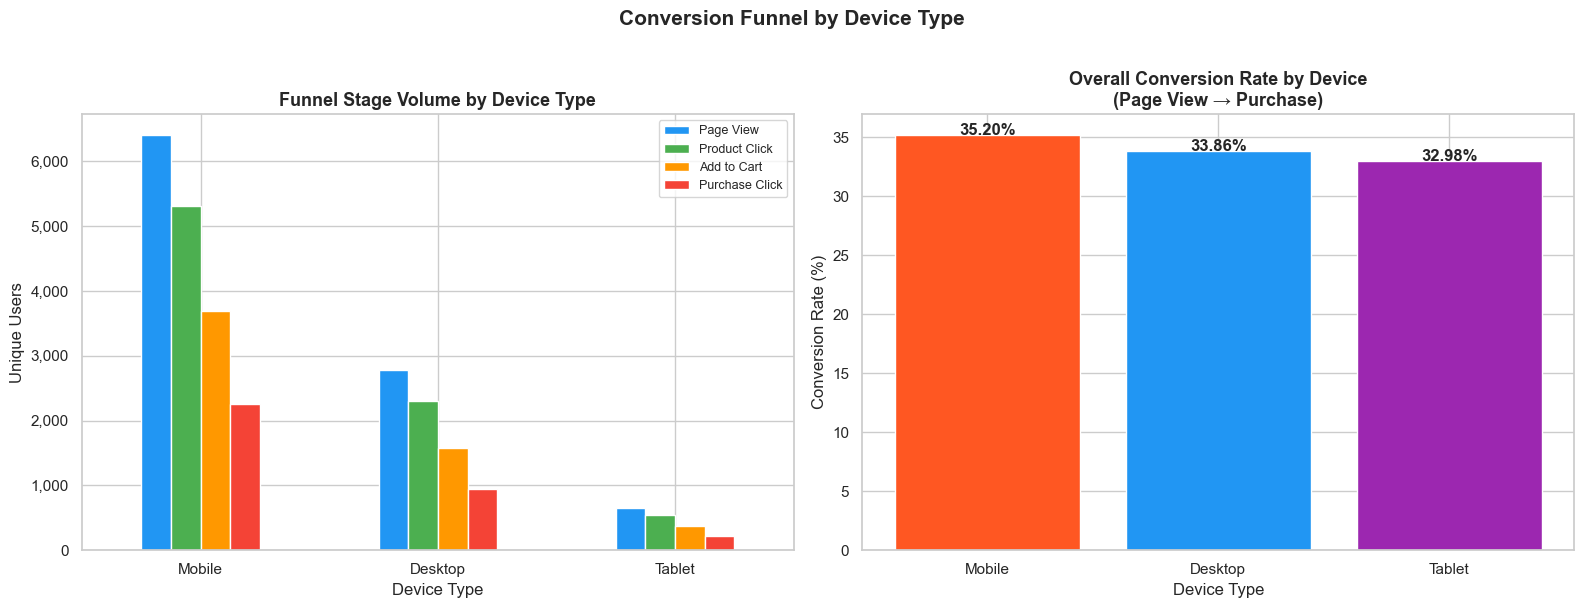

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Funnel stages by device ──────────────────────────────────────────
device_funnel[funnel_stages].plot(
    kind='bar', ax=axes[0],
    color=['#2196F3', '#4CAF50', '#FF9800', '#F44336']
)
axes[0].set_title('Funnel Stage Volume by Device Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Device Type')
axes[0].set_ylabel('Unique Users')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(stage_labels, fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ─── Conversion rate by device ────────────────────────────────────────
colors_d = ['#FF5722', '#2196F3', '#9C27B0']  # Mobile, Desktop, Tablet
bars = axes[1].bar(device_funnel.index, device_funnel['conv_rate'], color=colors_d)
axes[1].set_title('Overall Conversion Rate by Device\n(Page View → Purchase)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xlabel('Device Type')

for bar, v in zip(bars, device_funnel['conv_rate']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Conversion Funnel by Device Type', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\04_funnel_by_device.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Funnel by Device

> **If Desktop has a higher conversion rate than Mobile**, it confirms that the mobile checkout experience is a significant revenue bottleneck. Even a small improvement in mobile conversion (e.g., from 1% to 1.5%) would be enormous given the volume of mobile users.
>
> **Tablet users often behave more like Desktop than Mobile** — they browse leisurely and are likely in a comfortable, decision-making mindset. Ensure the tablet experience is not neglected.

---
## 🔎 Step 7 — Where in the Cart Journey Do Users Drop?

We look at users who added to cart but never purchased — this is the **cart abandonment** problem, one of the most costly in e-commerce.

In [9]:
# Users who added to cart
users_added_cart = set(events[events['event_type'] == 'add_to_cart']['user_id'].unique())

# Users who purchased
users_purchased = set(events[events['event_type'] == 'purchase_click']['user_id'].unique())

# Cart abandoners: added to cart but never purchased
cart_abandoners = users_added_cart - users_purchased

cart_abandonment_rate = len(cart_abandoners) / len(users_added_cart) * 100

print(f'Users who added to cart         : {len(users_added_cart):,}')
print(f'Users who completed purchase    : {len(users_purchased):,}')
print(f'Cart Abandoners                 : {len(cart_abandoners):,}')
print(f'Cart Abandonment Rate           : {cart_abandonment_rate:.1f}%')
print()
print(f'Industry average abandonment    : ~70%')
status = 'ABOVE AVERAGE ⚠️' if cart_abandonment_rate > 70 else 'BELOW AVERAGE ✅'
print(f'Cartly status                   : {status}')

Users who added to cart         : 5,628
Users who completed purchase    : 3,414
Cart Abandoners                 : 2,214
Cart Abandonment Rate           : 39.3%

Industry average abandonment    : ~70%
Cartly status                   : BELOW AVERAGE ✅


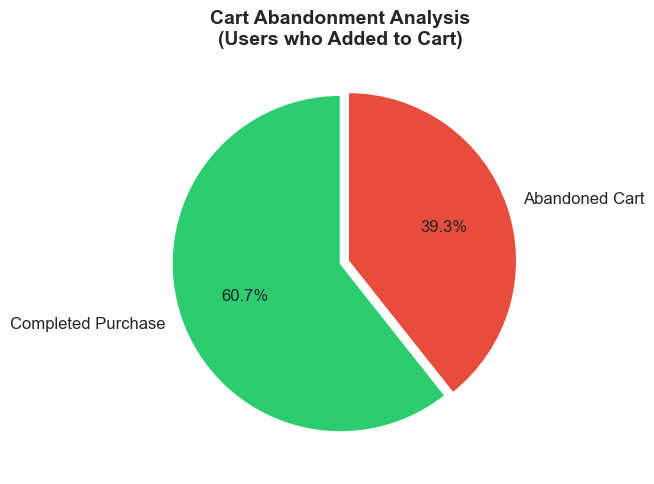

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['Completed Purchase', 'Abandoned Cart']
sizes  = [len(users_purchased & users_added_cart), len(cart_abandoners)]
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.05)

ax.pie(sizes, labels=labels, autopct='%1.1f%%',
       colors=colors, startangle=90, explode=explode,
       textprops={'fontsize': 12})

ax.set_title('Cart Abandonment Analysis\n(Users who Added to Cart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\04_cart_abandonment.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Cart Abandonment

> **Cart abandonment is the most direct revenue recovery opportunity in e-commerce.** Common reasons users abandon carts:
> - 💸 Unexpected costs at checkout (taxes, fees)
> - 🔐 Forced account creation before purchase
> - 😤 Complex or too many checkout steps
> - 💳 Payment method not supported
> - 🤔 Not ready to buy, just exploring
>
> **Recommended actions:**
> 1. Set up automated cart abandonment emails (sent 1h, 24h, 72h after abandonment)
> 2. Offer a small discount code in the reminder email
> 3. Simplify checkout to fewer steps
> 4. Add trust signals (SSL badge, secure payment logos, money-back guarantee)

---
## 🗺️ Step 8 — Full Funnel Visualisation (Waterfall Style)

A waterfall chart makes the cumulative drop-off visible at a glance.

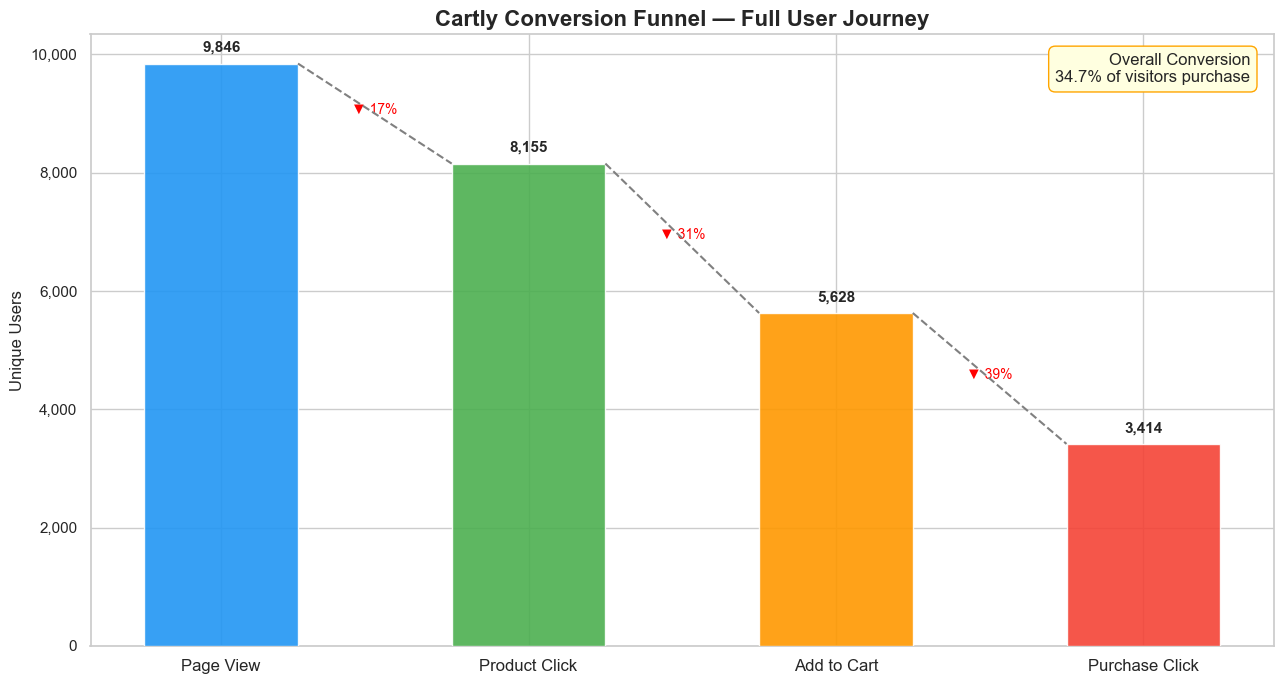

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))

x = range(len(funnel))
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

# Main bars
bars = ax.bar(x, funnel['unique_users'], color=bar_colors, width=0.5, alpha=0.9, zorder=3)

# Connect stages with lines showing drop-off
for i in range(len(funnel) - 1):
    ax.plot([i + 0.25, i + 0.75],
            [funnel['unique_users'].iloc[i], funnel['unique_users'].iloc[i + 1]],
            color='grey', linestyle='--', linewidth=1.5, zorder=4)

# Annotations
for i, row in funnel.iterrows():
    ax.text(i, row['unique_users'] + 200,
            f"{row['unique_users']:,}",
            ha='center', fontsize=11, fontweight='bold')

    if i > 0:
        prev = funnel['unique_users'].iloc[i - 1]
        drop = prev - row['unique_users']
        ax.text(i - 0.5, (prev + row['unique_users']) / 2,
                f'▼ {abs(funnel["step_conv_pct"].iloc[i]):.0f}%',
                ha='center', color='red', fontsize=10)

ax.set_xticks(list(x))
ax.set_xticklabels(stage_labels, fontsize=12)
ax.set_title('Cartly Conversion Funnel — Full User Journey', fontsize=16, fontweight='bold')
ax.set_ylabel('Unique Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Overall conversion annotation
final_conv = funnel['overall_conv_pct'].iloc[-1]
ax.text(0.98, 0.97,
        f'Overall Conversion\n{final_conv}% of visitors purchase',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\04_full_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Step 9 — Funnel Summary & Recommendations

In [ ]:
print('=' * 60)
print('       CARTLY FUNNEL Report CARD')
print('=' * 60)
for _, row in funnel.iterrows():
    bar = '█' * int(row['overall_conv_pct'] / 2)
    print(f"{row['stage_label']:<18} {row['unique_users']:>8,} users  {bar}  ({row['overall_conv_pct']}%)")
print('=' * 60)
print(f"\nOverall conversion: {funnel['overall_conv_pct'].iloc[-1]}% of page viewers purchase")
print(f"Cart abandonment rate: {cart_abandonment_rate:.1f}%")

       CARTLY FUNNEL Report CARD
Page View             9,846 users  ██████████████████████████████████████████████████  (100.0%)
Product Click         8,155 users  █████████████████████████████████████████  (82.8%)
Add to Cart           5,628 users  ████████████████████████████  (57.2%)
Purchase Click        3,414 users  █████████████████  (34.7%)

Overall conversion: 34.7% of page viewers purchase
Cart abandonment rate: 39.3%


---
## 🗺️ Final Summary — Funnel Findings & Action Plan

### 📌 Funnel Summary

| Funnel Stage | Users | Step Conv. | Drop-off |
|---|---|---|---|
| Page View | ~9,846 | — | — |
| Product Click | ~8,155 | ~82.8% | Major drop |
| Add to Cart | ~5,628 | ~57.2% | Moderate |
| Purchase Click | ~3,414 | ~34.7% | Critical |

### 🔑 Priority Action Plan

| Priority | Problem | Action |
|---|---|---|
| 🔴 P1 | Cart abandonment | Trigger abandonment email sequence within 1h |
| 🔴 P1 | Mobile conversion gap | Redesign mobile checkout — reduce steps, add trust badges |
| 🟠 P2 | Page View → Product Click | Improve product discovery: better search, featured sections |
| 🟠 P2 | High-view low-buy products | Add reviews, demo videos, clearer value proposition |
| 🟡 P3 | Weekend conversion dip | Run weekend-specific promotions with urgency timers |

### 💰 Revenue Impact Estimate

If cart abandonment rate drops by just 10 percentage points:
- More users complete purchase each month
- At average order value, this translates to significant monthly revenue recovery
- **This is the single highest-ROI improvement Cartly can make**
